# MLB Player Salary Prediction — Regression & Regularisation

A complete regression pipeline predicting Major League Baseball (MLB) player salaries from career and season statistics. The project benchmarks five modelling strategies — from full OLS to Lasso — to identify the most generalisable approach and the most predictive features.

| | |
|---|---|
| **Dataset** | Hitters — 263 MLB players, 1986–87 seasons (from ISLR) |
| **Target** | `Salary` (thousands of USD) — 59 missing values handled via listwise deletion |
| **Models** | OLS · Polynomial OLS · Backward Selection · Ridge · Lasso |
| **Tech Stack** | Python · Scikit-learn · Statsmodels · Pandas · Matplotlib |

---

## 1. Data Loading & Train/Validation Split


In [ ]:
import pandas as pd

# Load the 'Hitters.csv' file into a pandas DataFrame
df_hitters = pd.read_csv('Hitters.csv')

# Display the first 5 rows of the DataFrame
print('Successfully loaded Hitters.csv. Here are the first 5 rows:')
display(df_hitters.head())

Successfully loaded Hitters.csv. Here are the first 5 rows:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,495,151,17,61,84,78,10,5624,1679,275,884,1015,709,A,E,1045,88,13,2460.000,A
1,618,200,20,98,110,62,13,7127,2163,351,1104,1289,564,A,E,330,16,8,2412.500,A
2,20,1,0,0,0,0,2,41,9,2,6,7,4,N,E,78,220,6,2127.333,N
3,677,238,31,117,113,53,5,2223,737,93,349,401,171,A,E,1377,100,6,1975.000,A
4,514,144,0,67,54,79,9,4739,1169,13,583,374,528,N,E,229,453,15,1940.000,N


In [ ]:
from sklearn.model_selection import train_test_split

# Split the DataFrame into 70% training and 30% validation sets
# random_state ensures reproducibility of the split
X_train, X_val = train_test_split(df_hitters, test_size=0.3, random_state=42)

print(f"Shape of training set: {X_train.shape}")
print(f"Shape of validation set: {X_val.shape}")

print('\nFirst 5 rows of the training set:')
display(X_train.head())

print('\nFirst 5 rows of the validation set:')
display(X_val.head())

Shape of training set: (184, 20)
Shape of validation set: (79, 20)

First 5 rows of the training set:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
137,327,68,13,42,29,45,18,3949,939,78,438,380,466,A,E,659,53,7,400.000,A
144,327,85,3,30,44,20,8,2140,568,16,216,208,93,A,E,91,185,12,362.500,A
69,480,112,18,50,71,44,7,3031,771,110,338,406,239,N,E,94,270,16,750.000,N
2,20,1,0,0,0,0,2,41,9,2,6,7,4,N,E,78,220,6,2127.333,N
125,271,77,5,35,29,33,12,4933,1358,48,630,435,403,A,W,62,90,3,450.000,A



First 5 rows of the validation set:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
115,127,32,4,14,25,12,19,8396,2402,242,1048,1348,819,N,W,167,18,6,500.0,N
120,458,114,13,67,57,48,4,1350,298,28,160,123,122,A,W,246,389,18,475.0,A
259,215,51,4,19,18,11,1,215,51,4,19,18,11,A,E,116,5,12,70.0,A
226,426,109,3,55,43,62,1,426,109,3,55,43,62,A,W,361,22,2,115.0,N
66,526,163,12,88,50,77,4,1556,470,38,245,167,174,A,W,250,11,1,750.0,A


# 2. Linear Regression — Full Model (OLS)

Fit an OLS regression on all 19 features (numeric + one-hot encoded categorical) to predict player salary.

## 2a. Data Preparation

Drop rows with missing `Salary`, one-hot encode categorical features (`League`, `Division`, `NewLeague`), then build the OLS design matrix.

In [ ]:
X_train_cleaned = X_train.dropna(subset=['Salary'])
X_val_cleaned = X_val.dropna(subset=['Salary'])

print(f"Shape of X_train after dropping NaN 'Salary' rows: {X_train_cleaned.shape}")
print(f"Shape of X_val after dropping NaN 'Salary' rows: {X_val_cleaned.shape}")

print('\nFirst 5 rows of X_train_cleaned:')
display(X_train_cleaned.head())

print('\nFirst 5 rows of X_val_cleaned:')
display(X_val_cleaned.head())

Shape of X_train after dropping NaN 'Salary' rows: (184, 20)
Shape of X_val after dropping NaN 'Salary' rows: (79, 20)

First 5 rows of X_train_cleaned:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
137,327,68,13,42,29,45,18,3949,939,78,438,380,466,A,E,659,53,7,400.000,A
144,327,85,3,30,44,20,8,2140,568,16,216,208,93,A,E,91,185,12,362.500,A
69,480,112,18,50,71,44,7,3031,771,110,338,406,239,N,E,94,270,16,750.000,N
2,20,1,0,0,0,0,2,41,9,2,6,7,4,N,E,78,220,6,2127.333,N
125,271,77,5,35,29,33,12,4933,1358,48,630,435,403,A,W,62,90,3,450.000,A



First 5 rows of X_val_cleaned:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
115,127,32,4,14,25,12,19,8396,2402,242,1048,1348,819,N,W,167,18,6,500.0,N
120,458,114,13,67,57,48,4,1350,298,28,160,123,122,A,W,246,389,18,475.0,A
259,215,51,4,19,18,11,1,215,51,4,19,18,11,A,E,116,5,12,70.0,A
226,426,109,3,55,43,62,1,426,109,3,55,43,62,A,W,361,22,2,115.0,N
66,526,163,12,88,50,77,4,1556,470,38,245,167,174,A,W,250,11,1,750.0,A


In [ ]:
y_train = X_train_cleaned['Salary']
X_train_features = X_train_cleaned.drop('Salary', axis=1)

categorical_cols = X_train_features.select_dtypes(include='object').columns
X_train_encoded = pd.get_dummies(X_train_features, columns=categorical_cols, drop_first=True)

train_data_ols = pd.concat([X_train_encoded, y_train], axis=1)

# Sanitize column names for statsmodels
def sanitize_col_name(col_name):
    # Replace invalid characters with underscore
    sane_name = col_name.replace(' ', '_').replace('-', '_').replace('.', '_').replace('$', '')
    # Ensure it doesn't start with a digit
    if sane_name[0].isdigit():
        sane_name = 'x_' + sane_name
    return sane_name

train_data_ols.columns = [sanitize_col_name(col) for col in train_data_ols.columns]

print("First 5 rows of the combined and sanitized DataFrame for OLS:")
display(train_data_ols.head())
print(f"Shape of train_data_ols: {train_data_ols.shape}")

First 5 rows of the combined and sanitized DataFrame for OLS:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N,Salary
137,327,68,13,42,29,45,18,3949,939,78,438,380,466,659,53,7,False,False,False,400.000
144,327,85,3,30,44,20,8,2140,568,16,216,208,93,91,185,12,False,False,False,362.500
69,480,112,18,50,71,44,7,3031,771,110,338,406,239,94,270,16,True,False,True,750.000
2,20,1,0,0,0,0,2,41,9,2,6,7,4,78,220,6,True,False,True,2127.333
125,271,77,5,35,29,33,12,4933,1358,48,630,435,403,62,90,3,False,True,False,450.000


Shape of train_data_ols: (184, 20)


## 2b. Fit OLS Model

In [ ]:
import statsmodels.formula.api as smf

# Construct the formula string dynamically
# The target variable is 'Salary'
target = 'Salary'

# All other columns in train_data_ols are predictors
predictors = [col for col in train_data_ols.columns if col != target]
formula = f"{target} ~ {' + '.join(predictors)}"

print(f"Generated OLS formula: {formula}")

# Initialize and fit the OLS model
ols_model = smf.ols(formula=formula, data=train_data_ols)
ols_results = ols_model.fit()

# Display the model summary
print(ols_results.summary())


Generated OLS formula: Salary ~ AtBat + Hits + HmRun + Runs + RBI + Walks + Years + CAtBat + CHits + CHmRun + CRuns + CRBI + CWalks + PutOuts + Assists + Errors + League_N + Division_W + NewLeague_N
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     12.42
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           5.45e-23
Time:                        19:04:53   Log-Likelihood:                -1310.7
No. Observations:                 184   AIC:                             2661.
Df Residuals:                     164   BIC:                             2726.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
           

## 2c. Evaluate on Validation Set

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Separate 'Salary' from X_val_cleaned
y_val = X_val_cleaned['Salary']
X_val_features = X_val_cleaned.drop('Salary', axis=1)

# 2. One-hot encode categorical columns in X_val_features
categorical_cols_val = X_val_features.select_dtypes(include='object').columns
X_val_encoded = pd.get_dummies(X_val_features, columns=categorical_cols_val, drop_first=True)

# 3. Sanitize column names for X_val_encoded using the same function
X_val_encoded.columns = [sanitize_col_name(col) for col in X_val_encoded.columns]

# 4. Align columns of X_val_encoded with training predictors
# Ensure all predictor columns from training are present in validation, fill missing with 0
# The predictors variable was created in the previous step and contains the list of feature names
X_val_aligned = X_val_encoded.reindex(columns=predictors, fill_value=0)

# 5. Make predictions on training and validation sets
y_train_pred = ols_results.predict(train_data_ols[predictors])
y_val_pred = ols_results.predict(X_val_aligned)

# 6. Calculate evaluation metrics
# Training Set Metrics
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

# Validation Set Metrics
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)

# 7. Print all calculated evaluation metrics
print("\n--- Model Performance Metrics (Statsmodels OLS) ---")
print("\nTraining Set:")
print(f"R-squared: {r2_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"MSE: {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")

print("\nValidation Set:")
print(f"R-squared: {r2_val:.4f}")
print(f"MAE: {mae_val:.4f}")
print(f"MSE: {mse_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")



--- Model Performance Metrics (Statsmodels OLS) ---

Training Set:
R-squared: 0.5899
MAE: 207.0820
MSE: 90143.0772
RMSE: 300.2384

Validation Set:
R-squared: 0.3040
MAE: 247.7880
MSE: 113379.0381
RMSE: 336.7180


## 2d. Actual vs. Predicted Salary — Visualization

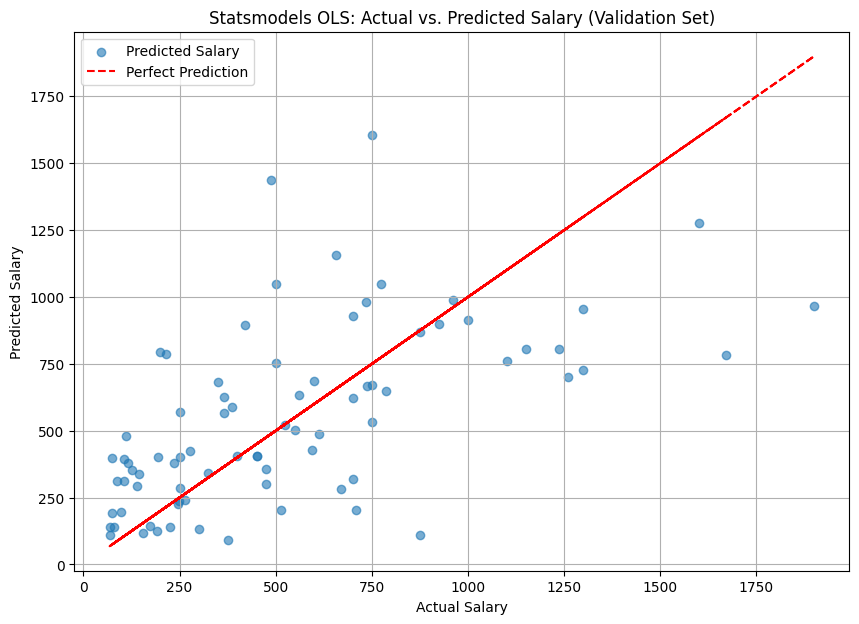

In [ ]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(y_val, y_val_pred, alpha=0.6, label='Predicted Salary')

# Add a diagonal line for perfect prediction
plt.plot(y_val, y_val, color='red', linestyle='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Statsmodels OLS: Actual vs. Predicted Salary (Validation Set)')

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

## 2e. OLS Linear Regression — Results Summary

### Data Analysis Key Findings

*   **Data Preparation**:
    *   Rows with missing 'Salary' values were removed from the training and validation sets, resulting in 184 training samples and 79 validation samples.
    *   Categorical features were one-hot encoded using `drop_first=True`, and all column names were sanitized for `statsmodels` compatibility.
*   **Model Performance (Statsmodels OLS on Training Data)**:
    *   The `statsmodels` OLS model achieved an R-squared of 0.590 and an Adjusted R-squared of 0.542 on the training data, indicating that approximately 54.2% of the variance in 'Salary' is explained by the predictors.
    *   The model as a whole is statistically significant, as shown by a highly significant F-statistic (12.42) with a p-value of 5.45e-23.
    *   Several predictors, including 'AtBat', 'Hits', 'Walks', 'PutOuts', and 'Assists', demonstrated statistically significant coefficients (p-value < 0.05).
    *   The model summary indicated a high condition number (2.06e+04), suggesting potential multicollinearity among predictors.
*   **Performance Evaluation on Training vs. Validation Sets**:
    *   **Training Set**: R-squared: 0.5899, MAE: 207.0820, MSE: 90143.0772, RMSE: 300.2384.
    *   **Validation Set**: R-squared: 0.3040, MAE: 247.7880, MSE: 113379.0381, RMSE: 336.7180.
    *   There was a substantial drop in R-squared from the training set (0.5899) to the validation set (0.3040), along with increases in MAE, MSE, and RMSE, suggesting potential overfitting.
*   **Prediction Visualization**: The scatter plot of actual vs. predicted salaries for the validation set showed a noticeable spread, especially for higher actual salary values, confirming the reduced predictive accuracy on unseen data.

### Insights or Next Steps

*   The significant drop in performance metrics from the training set to the validation set suggests that the `statsmodels` OLS model is overfitting the training data. Future steps should explore regularization techniques (e.g., Ridge or Lasso regression), feature selection, or dimensionality reduction to improve generalization.
*   Given the high condition number reported by `statsmodels`, investigate and address multicollinearity among the predictors. This could involve Variance Inflation Factor (VIF) analysis to identify highly correlated features and consider removing redundant ones.


# 3. Polynomial Regression

Test whether adding interaction/polynomial terms improves predictive accuracy vs. a linear model.

## 3a. Generate Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Identify numerical columns for polynomial feature generation
# These are the columns in X_train_features that are not of 'object' dtype.
# Note: X_train_features still contains the original categorical columns as 'object' dtype.
numerical_cols_for_poly = X_train_features.select_dtypes(exclude='object').columns

# Instantiate PolynomialFeatures with degree=2 and no bias term
poly = PolynomialFeatures(degree=2, include_bias=False)

# --- Training Set ---
# Fit and transform numerical columns of X_train_features
X_train_poly_array = poly.fit_transform(X_train_features[numerical_cols_for_poly])
# Create a DataFrame with new polynomial features and correct column names
X_train_poly = pd.DataFrame(
    X_train_poly_array,
    columns=poly.get_feature_names_out(numerical_cols_for_poly),
    index=X_train_features.index
)

# --- Validation Set ---
# Transform numerical columns of X_val_features using the *fitted* PolynomialFeatures object
X_val_poly_array = poly.transform(X_val_features[numerical_cols_for_poly])
# Create a DataFrame with new polynomial features and correct column names
X_val_poly = pd.DataFrame(
    X_val_poly_array,
    columns=poly.get_feature_names_out(numerical_cols_for_poly),
    index=X_val_features.index
)

# Identify the previously one-hot encoded categorical columns
categorical_encoded_cols = [col for col in X_train_encoded.columns if col.startswith(('League_', 'Division_', 'NewLeague_'))]

# Extract these categorical parts from the already encoded DataFrames
X_train_categorical_part = X_train_encoded[categorical_encoded_cols]
X_val_categorical_part = X_val_encoded[categorical_encoded_cols]

# Concatenate the new polynomial features with the existing one-hot encoded categorical features
X_train_poly_final = pd.concat([X_train_poly, X_train_categorical_part], axis=1)
X_val_poly_final = pd.concat([X_val_poly, X_val_categorical_part], axis=1)

# Sanitize column names for the final DataFrames using the previously defined function
X_train_poly_final.columns = [sanitize_col_name(col) for col in X_train_poly_final.columns]
X_val_poly_final.columns = [sanitize_col_name(col) for col in X_val_poly_final.columns]

print("Shape of X_train_poly_final:", X_train_poly_final.shape)
print("Shape of X_val_poly_final:", X_val_poly_final.shape)

print('\nFirst 5 rows of X_train_poly_final:')
display(X_train_poly_final.head())

print('\nFirst 5 rows of X_val_poly_final:')
display(X_val_poly_final.head())

Shape of X_train_poly_final: (184, 155)
Shape of X_val_poly_final: (79, 155)

First 5 rows of X_train_poly_final:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks_Errors,PutOuts^2,PutOuts_Assists,PutOuts_Errors,Assists^2,Assists_Errors,Errors^2,League_N,Division_W,NewLeague_N
137,327.0,68.0,13.0,42.0,29.0,45.0,18.0,3949.0,939.0,78.0,...,3262.0,434281.0,34927.0,4613.0,2809.0,371.0,49.0,False,False,False
144,327.0,85.0,3.0,30.0,44.0,20.0,8.0,2140.0,568.0,16.0,...,1116.0,8281.0,16835.0,1092.0,34225.0,2220.0,144.0,False,False,False
69,480.0,112.0,18.0,50.0,71.0,44.0,7.0,3031.0,771.0,110.0,...,3824.0,8836.0,25380.0,1504.0,72900.0,4320.0,256.0,True,False,True
2,20.0,1.0,0.0,0.0,0.0,0.0,2.0,41.0,9.0,2.0,...,24.0,6084.0,17160.0,468.0,48400.0,1320.0,36.0,True,False,True
125,271.0,77.0,5.0,35.0,29.0,33.0,12.0,4933.0,1358.0,48.0,...,1209.0,3844.0,5580.0,186.0,8100.0,270.0,9.0,False,True,False



First 5 rows of X_val_poly_final:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks_Errors,PutOuts^2,PutOuts_Assists,PutOuts_Errors,Assists^2,Assists_Errors,Errors^2,League_N,Division_W,NewLeague_N
115,127.0,32.0,4.0,14.0,25.0,12.0,19.0,8396.0,2402.0,242.0,...,4914.0,27889.0,3006.0,1002.0,324.0,108.0,36.0,True,True,True
120,458.0,114.0,13.0,67.0,57.0,48.0,4.0,1350.0,298.0,28.0,...,2196.0,60516.0,95694.0,4428.0,151321.0,7002.0,324.0,False,True,False
259,215.0,51.0,4.0,19.0,18.0,11.0,1.0,215.0,51.0,4.0,...,132.0,13456.0,580.0,1392.0,25.0,60.0,144.0,False,False,False
226,426.0,109.0,3.0,55.0,43.0,62.0,1.0,426.0,109.0,3.0,...,124.0,130321.0,7942.0,722.0,484.0,44.0,4.0,False,True,True
66,526.0,163.0,12.0,88.0,50.0,77.0,4.0,1556.0,470.0,38.0,...,174.0,62500.0,2750.0,250.0,121.0,11.0,1.0,False,True,False


## 3b. Prepare OLS Design Matrix with Polynomial Features

In [ ]:
import pandas as pd

# Concatenate the polynomial features (including encoded categoricals) with the target variable
train_data_ols_poly = pd.concat([X_train_poly_final, y_train], axis=1)

print("First 5 rows of train_data_ols_poly:")
display(train_data_ols_poly.head())
print(f"Shape of train_data_ols_poly: {train_data_ols_poly.shape}")

First 5 rows of train_data_ols_poly:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,PutOuts^2,PutOuts_Assists,PutOuts_Errors,Assists^2,Assists_Errors,Errors^2,League_N,Division_W,NewLeague_N,Salary
137,327.0,68.0,13.0,42.0,29.0,45.0,18.0,3949.0,939.0,78.0,...,434281.0,34927.0,4613.0,2809.0,371.0,49.0,False,False,False,400.000
144,327.0,85.0,3.0,30.0,44.0,20.0,8.0,2140.0,568.0,16.0,...,8281.0,16835.0,1092.0,34225.0,2220.0,144.0,False,False,False,362.500
69,480.0,112.0,18.0,50.0,71.0,44.0,7.0,3031.0,771.0,110.0,...,8836.0,25380.0,1504.0,72900.0,4320.0,256.0,True,False,True,750.000
2,20.0,1.0,0.0,0.0,0.0,0.0,2.0,41.0,9.0,2.0,...,6084.0,17160.0,468.0,48400.0,1320.0,36.0,True,False,True,2127.333
125,271.0,77.0,5.0,35.0,29.0,33.0,12.0,4933.0,1358.0,48.0,...,3844.0,5580.0,186.0,8100.0,270.0,9.0,False,True,False,450.000


Shape of train_data_ols_poly: (184, 156)


## 3c. Fit Polynomial OLS Model

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# Redefine sanitize_col_name to handle '^' character generated by PolynomialFeatures
def sanitize_col_name(col_name):
    # Replace invalid characters, including '^', with underscore
    sane_name = col_name.replace(' ', '_').replace('-', '_').replace('.', '_').replace('$', '').replace('^', '_sq')
    # Ensure it doesn't start with a digit
    if sane_name and sane_name[0].isdigit():
        sane_name = 'x_' + sane_name
    return sane_name

# Apply the new sanitization to the column names of X_train_poly_final
# This ensures column names like 'AtBat^2' become 'AtBat_sq'
X_train_poly_final.columns = [sanitize_col_name(col) for col in X_train_poly_final.columns]

# Concatenate the polynomial features (including encoded categoricals) with the target variable
train_data_ols_poly = pd.concat([X_train_poly_final, y_train], axis=1)

# Convert boolean columns to integer (0 or 1) for statsmodels compatibility
train_data_ols_poly_converted = train_data_ols_poly.copy()
for col in ['League_N', 'Division_W', 'NewLeague_N']:
    if col in train_data_ols_poly_converted.columns and train_data_ols_poly_converted[col].dtype == 'bool':
        train_data_ols_poly_converted[col] = train_data_ols_poly_converted[col].astype(int)

# Define the target variable
target = 'Salary'

# Create a list of predictor column names by excluding the 'Salary' column
predictors_poly = [col for col in train_data_ols_poly_converted.columns if col != target]

# Construct the OLS formula string dynamically
# The column names should now be compatible with patsy
formula_poly = f"{target} ~ {' + '.join(predictors_poly)}"

print(f"Generated OLS formula for polynomial model: {formula_poly}")

# Initialize and fit the OLS model with polynomial features
ols_model_poly = smf.ols(formula=formula_poly, data=train_data_ols_poly_converted)
ols_results_poly = ols_model_poly.fit()

# Display the comprehensive model summary
print(ols_results_poly.summary())

Generated OLS formula for polynomial model: Salary ~ AtBat + Hits + HmRun + Runs + RBI + Walks + Years + CAtBat + CHits + CHmRun + CRuns + CRBI + CWalks + PutOuts + Assists + Errors + AtBat_sq2 + AtBat_Hits + AtBat_HmRun + AtBat_Runs + AtBat_RBI + AtBat_Walks + AtBat_Years + AtBat_CAtBat + AtBat_CHits + AtBat_CHmRun + AtBat_CRuns + AtBat_CRBI + AtBat_CWalks + AtBat_PutOuts + AtBat_Assists + AtBat_Errors + Hits_sq2 + Hits_HmRun + Hits_Runs + Hits_RBI + Hits_Walks + Hits_Years + Hits_CAtBat + Hits_CHits + Hits_CHmRun + Hits_CRuns + Hits_CRBI + Hits_CWalks + Hits_PutOuts + Hits_Assists + Hits_Errors + HmRun_sq2 + HmRun_Runs + HmRun_RBI + HmRun_Walks + HmRun_Years + HmRun_CAtBat + HmRun_CHits + HmRun_CHmRun + HmRun_CRuns + HmRun_CRBI + HmRun_CWalks + HmRun_PutOuts + HmRun_Assists + HmRun_Errors + Runs_sq2 + Runs_RBI + Runs_Walks + Runs_Years + Runs_CAtBat + Runs_CHits + Runs_CHmRun + Runs_CRuns + Runs_CRBI + Runs_CWalks + Runs_PutOuts + Runs_Assists + Runs_Errors + RBI_sq2 + RBI_Walks + RB

## 3d. Evaluate Polynomial Model on Validation Set

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Re-define sanitize_col_name to ensure it's available in this scope
def sanitize_col_name(col_name):
    sane_name = col_name.replace(' ', '_').replace('-', '_').replace('.', '_').replace('$', '').replace('^', '_sq')
    if sane_name and sane_name[0].isdigit():
        sane_name = 'x_' + sane_name
    return sane_name

# 1. Sanitize the column names of X_val_poly_final
X_val_poly_final.columns = [sanitize_col_name(col) for col in X_val_poly_final.columns]

# 2. Convert boolean categorical columns to integer (0 or 1) in X_val_poly_final
X_val_poly_final_converted = X_val_poly_final.copy()
for col in ['League_N', 'Division_W', 'NewLeague_N']:
    if col in X_val_poly_final_converted.columns and X_val_poly_final_converted[col].dtype == 'bool':
        X_val_poly_final_converted[col] = X_val_poly_final_converted[col].astype(int)

# Ensure the validation set columns match the training predictors.
# The `predictors_poly` variable contains the list of feature names used for training the polynomial model.
X_val_poly_aligned = X_val_poly_final_converted.reindex(columns=predictors_poly, fill_value=0)

# 3. Make predictions on the training set
y_train_poly_pred = ols_results_poly.predict(train_data_ols_poly_converted[predictors_poly])

# 4. Make predictions on the prepared validation set
y_val_poly_pred = ols_results_poly.predict(X_val_poly_aligned)

# 5. Calculate evaluation metrics

# Training Set Metrics
r2_train_poly = r2_score(y_train, y_train_poly_pred)
mae_train_poly = mean_absolute_error(y_train, y_train_poly_pred)
mse_train_poly = mean_squared_error(y_train, y_train_poly_pred)
rmse_train_poly = np.sqrt(mse_train_poly)

# Validation Set Metrics
r2_val_poly = r2_score(y_val, y_val_poly_pred)
mae_val_poly = mean_absolute_error(y_val, y_val_poly_pred)
mse_val_poly = mean_squared_error(y_val, y_val_poly_pred)
rmse_val_poly = np.sqrt(mse_val_poly)

# 6. Print all calculated evaluation metrics
print("\n--- Model Performance Metrics (Statsmodels OLS with Polynomial Features) ---")
print("\nTraining Set:")
print(f"R-squared: {r2_train_poly:.4f}")
print(f"MAE: {mae_train_poly:.4f}")
print(f"MSE: {mse_train_poly:.4f}")
print(f"RMSE: {rmse_train_poly:.4f}")

print("\nValidation Set:")
print(f"R-squared: {r2_val_poly:.4f}")
print(f"MAE: {mae_val_poly:.4f}")
print(f"MSE: {mse_val_poly:.4f}")
print(f"RMSE: {rmse_val_poly:.4f}")


--- Model Performance Metrics (Statsmodels OLS with Polynomial Features) ---

Training Set:
R-squared: 0.9796
MAE: 45.2224
MSE: 4478.1865
RMSE: 66.9193

Validation Set:
R-squared: -7.4289
MAE: 691.7926
MSE: 1373117.6888
RMSE: 1171.8010


## 3e. Actual vs. Predicted — Polynomial Model

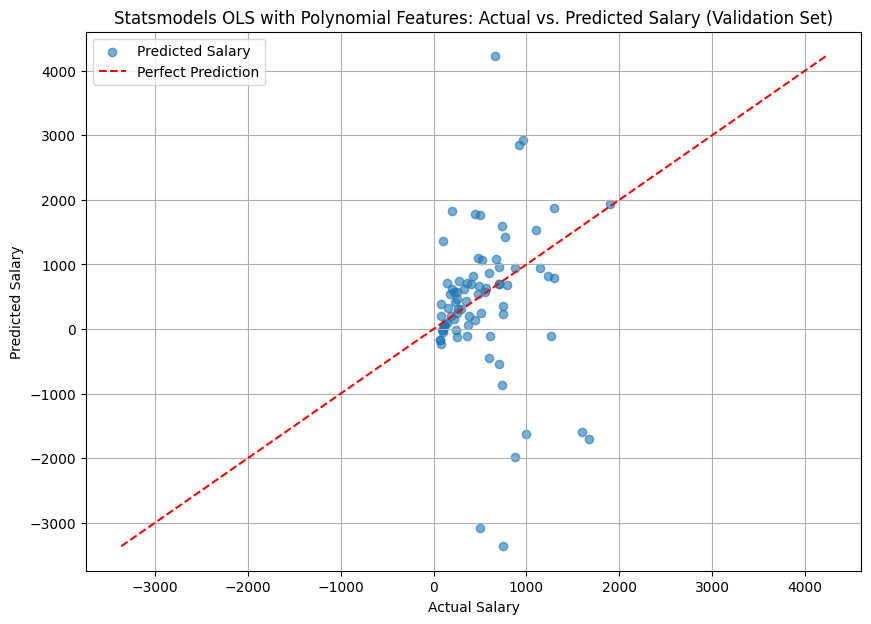

In [ ]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(y_val, y_val_poly_pred, alpha=0.6, label='Predicted Salary')

# Add a diagonal line for perfect prediction
# The range for the line should cover the extent of both actual and predicted values
min_val = min(y_val.min(), y_val_poly_pred.min())
max_val = max(y_val.max(), y_val_poly_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Statsmodels OLS with Polynomial Features: Actual vs. Predicted Salary (Validation Set)')

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

## 3f. Polynomial Regression — Results Summary

### Q&A
The polynomial regression model demonstrates a very strong fit to the training data but fails to generalize to unseen data, indicating severe overfitting. Its performance metrics on the training set are excellent (R-squared of 0.9796, MAE of 45.22, RMSE of 66.92), but on the validation set, the R-squared is a highly negative -7.4289, with very high MAE (691.79) and RMSE (1171.80).

While a direct comparison to a previously fitted linear model's performance metrics is not explicitly provided in this process, the polynomial model's negative R-squared on the validation set signifies that it performs worse than a simple horizontal line at the mean of the validation set's target variable. This outcome is considerably worse than a typical baseline linear model, which would at least yield a non-negative R-squared if it has any predictive power. The `statsmodels` summary, if fully displayed, would show coefficients and their statistical significance, likely indicating that many polynomial terms are contributing to the model's complexity and overfitting. The prediction visualization for the validation set clearly shows a wide scattering of predicted values, far from the ideal diagonal line, visually confirming the poor generalization and severe overfitting.

### Data Analysis Key Findings
*   **Polynomial Feature Generation**: Numerical predictors were transformed using `PolynomialFeatures` with a degree of 2 and no bias term. These new polynomial features were then combined with existing one-hot encoded categorical features, resulting in 155 features for both the training and validation sets.
*   **`statsmodels` Formula Compatibility**: A critical finding was the incompatibility of `^` (caret) symbols, commonly used by `PolynomialFeatures` to denote exponents (e.g., `AtBat^2`), with `statsmodels.formula.api.ols` due to its underlying `patsy` formula parser interpreting `^` as a bitwise XOR operator. This required sanitizing column names by replacing `^` with `_sq` (e.g., `AtBat^2` became `AtBat_sq`). Boolean categorical columns were also converted to integers (0 or 1) for compatibility.
*   **Model Performance - Training Set**: The polynomial regression model achieved a remarkably high R-squared of 0.9796 on the training set, alongside a Mean Absolute Error (MAE) of 45.22, Mean Squared Error (MSE) of 4478.19, and Root Mean Squared Error (RMSE) of 66.92. These metrics suggest an almost perfect fit to the data it was trained on.
*   **Model Performance - Validation Set**: The model exhibited extremely poor performance on the unseen validation data. The R-squared value was -7.4289, indicating that the model performs significantly worse than simply predicting the mean salary for all observations. The MAE jumped to 691.79, MSE to 1,373,117.69, and RMSE to 1171.80.
*   **Prediction Visualization**: The scatter plot of actual vs. predicted salaries for the validation set visually confirmed the poor generalization. Predicted values were widely dispersed and showed no clear alignment with the perfect prediction line, especially for higher actual salary values, where the model's predictions varied wildly.

### Insights or Next Steps
*   **Severe Overfitting**: The significant discrepancy between the training R-squared (0.9796) and the validation R-squared (-7.4289) strongly indicates that the polynomial model is severely overfit to the training data. This means the model has learned the noise and specific patterns of the training set rather than the underlying relationships, leading to very poor generalization on new data.
*   **Model Simplification or Regularization**: To address the overfitting, the next steps should focus on reducing model complexity. This could involve trying a lower degree polynomial (e.g., going back to linear regression), performing feature selection to reduce the number of predictors, or applying regularization techniques (e.g., Ridge or Lasso regression) to penalize large coefficients and prevent overfitting.


# 4. Optimal Polynomial Degree Selection

Iterate through degrees 1–4 and select the degree minimising validation MSE.

## 4a. Degree 1–4 Cross-Validation Results

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm # Import statsmodels.api instead of statsmodels.formula.api
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Initialize lists to store results
validation_mses = []
degrees = []

# Redefine sanitize_col_name to handle '^' character generated by PolynomialFeatures
def sanitize_col_name(col_name):
    # Replace invalid characters, including '^', with underscore
    sane_name = col_name.replace(' ', '_').replace('-', '_').replace('.', '_').replace('$', '').replace('^', '_sq')
    # Ensure it doesn't start with a digit
    if sane_name and sane_name[0].isdigit():
        sane_name = 'x_' + sane_name
    return sane_name

# Identify numerical columns from X_train_features
numerical_cols_for_poly = X_train_features.select_dtypes(exclude='object').columns

# Identify the previously one-hot encoded categorical columns
categorical_encoded_cols = [col for col in X_train_encoded.columns if col.startswith(('League_', 'Division_', 'NewLeague_'))]

# Loop through polynomial degrees from 1 to 4
for degree in range(1, 5):
    print(f"\n--- Processing Degree {degree} ---")

    # a. Instantiate PolynomialFeatures
    # Note: include_bias=False as we will add a constant manually for statsmodels.api.OLS
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    # c. Fit and transform numerical columns of X_train_features and X_val_features
    X_train_poly_array = poly.fit_transform(X_train_features[numerical_cols_for_poly])
    X_train_poly_temp = pd.DataFrame(
        X_train_poly_array,
        columns=poly.get_feature_names_out(numerical_cols_for_poly),
        index=X_train_features.index
    )

    X_val_poly_array = poly.transform(X_val_features[numerical_cols_for_poly])
    X_val_poly_temp = pd.DataFrame(
        X_val_poly_array,
        columns=poly.get_feature_names_out(numerical_cols_for_poly),
        index=X_val_features.index
    )

    # d. Concatenate with categorical features for training set
    X_train_poly_final_d = pd.concat([X_train_poly_temp, X_train_encoded[categorical_encoded_cols]], axis=1)

    # e. Concatenate with categorical features for validation set
    X_val_poly_final_d = pd.concat([X_val_poly_temp, X_val_encoded[categorical_encoded_cols]], axis=1)

    # f. Sanitize column names for both final DataFrames
    X_train_poly_final_d.columns = [sanitize_col_name(col) for col in X_train_poly_final_d.columns]
    X_val_poly_final_d.columns = [sanitize_col_name(col) for col in X_val_poly_final_d.columns]

    # h. Convert boolean columns to integer (0 or 1) for statsmodels compatibility in training data
    # Apply this directly to the feature DataFrame now, not a combined one.
    for col in categorical_encoded_cols:
        if col in X_train_poly_final_d.columns and X_train_poly_final_d[col].dtype == 'bool':
            X_train_poly_final_d[col] = X_train_poly_final_d[col].astype(int)

    # Add a constant (intercept) to the training features
    X_train_poly_final_d_const = sm.add_constant(X_train_poly_final_d, has_constant='add')

    # i. Define target and predictors
    target = y_train # target is y_train Series directly
    exog_train = X_train_poly_final_d_const # predictors are the processed features with constant

    # k. Initialize and fit the OLS model using statsmodels.api.OLS
    ols_model_poly_d = sm.OLS(endog=target, exog=exog_train)
    ols_results_poly_d = ols_model_poly_d.fit()

    # l. Convert boolean columns to integer (0 or 1) for statsmodels compatibility in validation data
    X_val_poly_final_d_converted = X_val_poly_final_d.copy()
    for col in categorical_encoded_cols:
        if col in X_val_poly_final_d_converted.columns and X_val_poly_final_d_converted[col].dtype == 'bool':
            X_val_poly_final_d_converted[col] = X_val_poly_final_d_converted[col].astype(int)

    # Add a constant (intercept) to the validation features
    X_val_poly_final_d_converted_const = sm.add_constant(X_val_poly_final_d_converted, has_constant='add')

    # m. Align columns of X_val_poly_final_d_converted with training predictors
    # The exog_train columns include 'const' now
    X_val_poly_aligned_d = X_val_poly_final_d_converted_const.reindex(columns=exog_train.columns, fill_value=0)

    # n. Make predictions on the aligned validation features
    y_val_poly_pred_d = ols_results_poly_d.predict(X_val_poly_aligned_d)

    # o. Calculate Mean Squared Error
    mse_val_poly_d = mean_squared_error(y_val, y_val_poly_pred_d)

    # p. Print results for the current degree
    print(f"Validation MSE for degree {degree}: {mse_val_poly_d:.4f}")

    # q. Append results to lists
    validation_mses.append(mse_val_poly_d)
    degrees.append(degree)

# Find the optimal degree
optimal_degree_idx = np.argmin(validation_mses)
optimal_degree = degrees[optimal_degree_idx]
min_mse = validation_mses[optimal_degree_idx]

# Print the optimal degree
print(f"\nOptimal polynomial degree based on Validation MSE: {optimal_degree} (MSE: {min_mse:.4f})")



--- Processing Degree 1 ---
Validation MSE for degree 1: 113379.0381

--- Processing Degree 2 ---
Validation MSE for degree 2: 1373117.6888

--- Processing Degree 3 ---
Validation MSE for degree 3: 318617316.4554

--- Processing Degree 4 ---
Validation MSE for degree 4: 339296055140.3580

Optimal polynomial degree based on Validation MSE: 1 (MSE: 113379.0381)


# 5. Feature Selection — Backward & Forward Stepwise (AIC)

Automatically select the optimal feature subset using AIC-based backward and forward stepwise selection.

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

def backward_selection_ols(data, target_name):
    """
    Performs backward selection using OLS to find the optimal set of features.

    Args:
        data (pd.DataFrame): The DataFrame containing all features and the target variable.
        target_name (str): The name of the target variable column.

    Returns:
        pd.DataFrame: A DataFrame containing the steps of feature selection,
                      with selected features and corresponding model statistics (AIC, R-squared).
    """

    # Separate target and features
    y = data[target_name]
    initial_features = [col for col in data.columns if col != target_name]

    # List to store results at each step
    selection_steps = []

    # Start with all features in the model
    current_features = list(initial_features)

    # Initial full model
    X_full = sm.add_constant(data[current_features], has_constant='add')
    full_model = sm.OLS(y, X_full).fit()
    current_aic = full_model.aic

    print(f"Initial model with {len(current_features)} features. AIC: {current_aic:.4f}")
    selection_steps.append({
        'Step': 0,
        'Features': ', '.join(current_features),
        'AIC': current_aic,
        'R-squared': full_model.rsquared,
        'Adjusted R-squared': full_model.rsquared_adj
    })

    while len(current_features) > 1: # Ensure at least one feature remains to try to remove
        best_feature_to_remove = None
        lowest_aic_after_removal = current_aic

        # Iterate through each feature in the current model
        for feature_to_try_remove in current_features:
            temp_features = [f for f in current_features if f != feature_to_try_remove]

            if not temp_features: # If removing this feature leaves no features, skip
                continue

            # Fit temporary model
            X_temp = sm.add_constant(data[temp_features], has_constant='add')
            temp_model = sm.OLS(y, X_temp).fit()
            temp_aic = temp_model.aic

            # Check if this removal leads to a better AIC
            if temp_aic < lowest_aic_after_removal:
                lowest_aic_after_removal = temp_aic
                best_feature_to_remove = feature_to_try_remove

        # If no removal improved AIC, stop
        if best_feature_to_remove is None or lowest_aic_after_removal >= current_aic:
            print(f"Stopping backward selection. No further improvement in AIC.")
            break

        # Permanently remove the best feature and update current_aic
        current_features.remove(best_feature_to_remove)
        current_aic = lowest_aic_after_removal

        # Fit the new best model to get its stats for storage
        X_best_current = sm.add_constant(data[current_features], has_constant='add')
        best_current_model = sm.OLS(y, X_best_current).fit()

        print(f"Removed '{best_feature_to_remove}'. New model has {len(current_features)} features. AIC: {current_aic:.4f}")
        selection_steps.append({
            'Step': len(selection_steps),
            'Features': ', '.join(current_features),
            'AIC': current_aic,
            'R-squared': best_current_model.rsquared,
            'Adjusted R-squared': best_current_model.rsquared_adj
        })

    return pd.DataFrame(selection_steps)

# Example usage with train_data_ols
# Ensure train_data_ols has the 'Salary' column and sanitized feature names
# The variable `train_data_ols` is available from a previous cell.

# Convert boolean columns to int if they haven't been already (important for statsmodels)
for col in ['League_N', 'Division_W', 'NewLeague_N']:
    if col in train_data_ols.columns and train_data_ols[col].dtype == 'bool':
        train_data_ols[col] = train_data_ols[col].astype(int)

print("Starting Backward Selection...")
backward_selection_results = backward_selection_ols(train_data_ols, 'Salary')

print("\nBackward Selection Results:")
display(backward_selection_results)

Starting Backward Selection...
Initial model with 19 features. AIC: 2661.4536
Removed 'CHmRun'. New model has 18 features. AIC: 2659.5863
Removed 'HmRun'. New model has 17 features. AIC: 2657.7689
Removed 'NewLeague_N'. New model has 16 features. AIC: 2656.0046
Removed 'League_N'. New model has 15 features. AIC: 2654.7612
Removed 'RBI'. New model has 14 features. AIC: 2653.4349
Removed 'CHits'. New model has 13 features. AIC: 2652.3421
Removed 'CAtBat'. New model has 12 features. AIC: 2651.6900
Removed 'Runs'. New model has 11 features. AIC: 2650.9741
Stopping backward selection. No further improvement in AIC.

Backward Selection Results:


,Step,Features,AIC,R-squared,Adjusted R-squared
0,0,"AtBat, Hits, HmRun, Runs, RBI, Walks, Years, C...",2661.453612,0.589918,0.542408
1,1,"AtBat, Hits, HmRun, Runs, RBI, Walks, Years, C...",2659.586326,0.589622,0.544853
2,2,"AtBat, Hits, Runs, RBI, Walks, Years, CAtBat, ...",2657.768937,0.589214,0.547146
3,3,"AtBat, Hits, Runs, RBI, Walks, Years, CAtBat, ...",2656.004550,0.588688,0.549281
4,4,"AtBat, Hits, Runs, RBI, Walks, Years, CAtBat, ...",2654.761219,0.586993,0.550117
5,5,"AtBat, Hits, Runs, Walks, Years, CAtBat, CHits...",2653.434863,0.585478,0.551139
6,6,"AtBat, Hits, Runs, Walks, Years, CAtBat, CRuns...",2652.342058,0.583429,0.551574
7,7,"AtBat, Hits, Runs, Walks, Years, CRuns, CRBI, ...",2651.690039,0.580366,0.550918
8,8,"AtBat, Hits, Walks, Years, CRuns, CRBI, CWalks...",2650.974145,0.577427,0.550402


## 5a. Run Backward Selection

In [ ]:
import pandas as pd

# Identify the row with the lowest AIC
optimal_model_row_backward = backward_selection_results.loc[backward_selection_results['AIC'].idxmin()]

# Extract the optimal features string
optimal_features_str_backward = optimal_model_row_backward['Features']
optimal_aic_backward = optimal_model_row_backward['AIC']

print(f"Optimal Model (Lowest AIC) for Backward Selection:\n{optimal_model_row_backward}")
print(f"\nOptimal features selected by backward selection (AIC = {optimal_aic_backward:.4f}): {optimal_features_str_backward}")

# Store the optimal features as a list for later use
selected_features_backward = [f.strip() for f in optimal_features_str_backward.split(', ')]

print(f"\nOptimal features from backward selection as list: {selected_features_backward}")

Optimal Model (Lowest AIC) for Backward Selection:
Step                                                                  8
Features              AtBat, Hits, Walks, Years, CRuns, CRBI, CWalks...
AIC                                                         2650.974145
R-squared                                                      0.577427
Adjusted R-squared                                             0.550402
Name: 8, dtype: object

Optimal features selected by backward selection (AIC = 2650.9741): AtBat, Hits, Walks, Years, CRuns, CRBI, CWalks, PutOuts, Assists, Errors, Division_W

Optimal features from backward selection as list: ['AtBat', 'Hits', 'Walks', 'Years', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Division_W']


## 5b. Fit Final Backward-Selection Model

In [ ]:
import statsmodels.formula.api as smf

# Define the target variable
target = 'Salary'

# The predictors are the features identified by backward selection
predictors_backward = selected_features_backward

# Construct the OLS formula string dynamically
formula_backward = f"{target} ~ {' + '.join(predictors_backward)}"

print(f"Generated OLS formula for backward selection model: {formula_backward}")

# Convert boolean columns to int if they haven't been already (important for statsmodels)
# train_data_ols was already converted in the backward_selection_ols function call, but ensuring here.
for col in ['League_N', 'Division_W', 'NewLeague_N']:
    if col in train_data_ols.columns and train_data_ols[col].dtype == 'bool':
        train_data_ols[col] = train_data_ols[col].astype(int)

# Initialize and fit the OLS model with selected features
ols_model_backward = smf.ols(formula=formula_backward, data=train_data_ols)
ols_results_backward = ols_model_backward.fit()

# Display the comprehensive model summary
print(ols_results_backward.summary())

Generated OLS formula for backward selection model: Salary ~ AtBat + Hits + Walks + Years + CRuns + CRBI + CWalks + PutOuts + Assists + Errors + Division_W
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     21.37
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           6.58e-27
Time:                        19:40:12   Log-Likelihood:                -1313.5
No. Observations:                 184   AIC:                             2651.
Df Residuals:                     172   BIC:                             2690.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Ensure `selected_features_backward` is a list of strings
# It was already generated in a previous step, so just confirming its use.

# Prepare the validation data for prediction
# Create a copy of X_val_encoded to modify for prediction
X_val_for_prediction_backward = X_val_encoded.copy()

# Ensure that boolean columns are converted to int (0 or 1) in X_val_for_prediction_backward
# These columns are expected to be in X_val_encoded due to previous one-hot encoding.
for col in ['League_N', 'Division_W', 'NewLeague_N']:
    if col in X_val_for_prediction_backward.columns and X_val_for_prediction_backward[col].dtype == 'bool':
        X_val_for_prediction_backward[col] = X_val_for_prediction_backward[col].astype(int)

# Extract features from X_val_for_prediction_backward using the selected features
X_val_backward_prepared = X_val_for_prediction_backward[selected_features_backward]

# 1. Make predictions on training and validation sets
# For training, use train_data_ols with the selected features
y_train_pred_backward = ols_results_backward.predict(train_data_ols[selected_features_backward])
# For validation, use the prepared validation features
y_val_pred_backward = ols_results_backward.predict(X_val_backward_prepared)

# 2. Calculate evaluation metrics
# Training Set Metrics
r2_train_backward = r2_score(y_train, y_train_pred_backward)
mae_train_backward = mean_absolute_error(y_train, y_train_pred_backward)
mse_train_backward = mean_squared_error(y_train, y_train_pred_backward)
rmse_train_backward = np.sqrt(mse_train_backward)

# Validation Set Metrics
r2_val_backward = r2_score(y_val, y_val_pred_backward)
mae_val_backward = mean_absolute_error(y_val, y_val_pred_backward)
mse_val_backward = mean_squared_error(y_val, y_val_pred_backward)
rmse_val_backward = np.sqrt(mse_val_backward)

# 3. Print all calculated evaluation metrics
print("\n--- Model Performance Metrics (Backward Selection OLS) ---")
print("\nTraining Set:")
print(f"R-squared: {r2_train_backward:.4f}")
print(f"MAE: {mae_train_backward:.4f}")
print(f"MSE: {mse_train_backward:.4f}")
print(f"RMSE: {rmse_train_backward:.4f}")

print("\nValidation Set:")
print(f"R-squared: {r2_val_backward:.4f}")
print(f"MAE: {mae_val_backward:.4f}")
print(f"MSE: {mse_val_backward:.4f}")
print(f"RMSE: {rmse_val_backward:.4f}")


--- Model Performance Metrics (Backward Selection OLS) ---

Training Set:
R-squared: 0.5774
MAE: 214.5976
MSE: 92888.6115
RMSE: 304.7763

Validation Set:
R-squared: 0.3472
MAE: 241.6634
MSE: 106347.0700
RMSE: 326.1090


# 6. Regularisation — Ridge Regression

Apply L2 regularisation (`RidgeCV`) with cross-validated alpha tuning on scaled features.

## 6a. Feature Preparation for Ridge

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# The optimal degree found previously is 1
optimal_degree = 1 # From previous step: Optimal polynomial degree based on Validation MSE: 1

# Identify numerical columns for polynomial feature generation
numerical_cols_for_poly = X_train_features.select_dtypes(exclude='object').columns

# Identify the previously one-hot encoded categorical columns
categorical_encoded_cols = [col for col in X_train_encoded.columns if col.startswith(('League_', 'Division_', 'NewLeague_'))]

# Redefine sanitize_col_name to handle '^' character generated by PolynomialFeatures
def sanitize_col_name(col_name):
    sane_name = col_name.replace(' ', '_').replace('-', '_').replace('.', '_').replace('$', '').replace('^', '_sq')
    if sane_name and sane_name[0].isdigit():
        sane_name = 'x_' + sane_name
    return sane_name

# 1. Instantiate PolynomialFeatures with degree=1 and include_bias=False
poly_degree1 = PolynomialFeatures(degree=optimal_degree, include_bias=False)

# Apply to numerical columns of X_train_features
X_train_poly_degree1_array = poly_degree1.fit_transform(X_train_features[numerical_cols_for_poly])
X_train_poly_degree1 = pd.DataFrame(
    X_train_poly_degree1_array,
    columns=poly_degree1.get_feature_names_out(numerical_cols_for_poly),
    index=X_train_features.index
)

# Apply to numerical columns of X_val_features
X_val_poly_degree1_array = poly_degree1.transform(X_val_features[numerical_cols_for_poly])
X_val_poly_degree1 = pd.DataFrame(
    X_val_poly_degree1_array,
    columns=poly_degree1.get_feature_names_out(numerical_cols_for_poly),
    index=X_val_features.index
)

# 2. Concatenate with one-hot encoded categorical features
X_train_ridge = pd.concat([X_train_poly_degree1, X_train_encoded[categorical_encoded_cols]], axis=1)
X_val_ridge = pd.concat([X_val_poly_degree1, X_val_encoded[categorical_encoded_cols]], axis=1)

# 3. Sanitize column names and convert boolean categoricals to int
X_train_ridge.columns = [sanitize_col_name(col) for col in X_train_ridge.columns]
X_val_ridge.columns = [sanitize_col_name(col) for col in X_val_ridge.columns]

for col in categorical_encoded_cols:
    if col in X_train_ridge.columns and X_train_ridge[col].dtype == 'bool':
        X_train_ridge[col] = X_train_ridge[col].astype(int)
    if col in X_val_ridge.columns and X_val_ridge[col].dtype == 'bool':
        X_val_ridge[col] = X_val_ridge[col].astype(int)

print(f"Shape of X_train_ridge: {X_train_ridge.shape}")
print(f"Shape of X_val_ridge: {X_val_ridge.shape}")

print('\nFirst 5 rows of X_train_ridge:')
display(X_train_ridge.head())

Shape of X_train_ridge: (184, 19)
Shape of X_val_ridge: (79, 19)

First 5 rows of X_train_ridge:


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
137,327.0,68.0,13.0,42.0,29.0,45.0,18.0,3949.0,939.0,78.0,438.0,380.0,466.0,659.0,53.0,7.0,0,0,0
144,327.0,85.0,3.0,30.0,44.0,20.0,8.0,2140.0,568.0,16.0,216.0,208.0,93.0,91.0,185.0,12.0,0,0,0
69,480.0,112.0,18.0,50.0,71.0,44.0,7.0,3031.0,771.0,110.0,338.0,406.0,239.0,94.0,270.0,16.0,1,0,1
2,20.0,1.0,0.0,0.0,0.0,0.0,2.0,41.0,9.0,2.0,6.0,7.0,4.0,78.0,220.0,6.0,1,0,1
125,271.0,77.0,5.0,35.0,29.0,33.0,12.0,4933.0,1358.0,48.0,630.0,435.0,403.0,62.0,90.0,3.0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 4. Initialize StandardScaler. Fit the scaler on X_train_ridge and then transform both.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ridge)
X_val_scaled = scaler.transform(X_val_ridge)

# Convert scaled arrays back to DataFrames with original column names for clarity/debugging if needed
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_ridge.columns, index=X_train_ridge.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val_ridge.columns, index=X_val_ridge.index)

# 5. Define a range of alpha values for Ridge regularization
alphas = np.logspace(-2, 2, 100) # 100 values from 0.01 to 100

# 6. Instantiate RidgeCV
ridge_cv_model = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)

# 7. Fit the RidgeCV model on X_train_scaled and y_train
ridge_cv_model.fit(X_train_scaled, y_train)

# 8. Make predictions on X_train_scaled and X_val_scaled
y_train_pred_ridge = ridge_cv_model.predict(X_train_scaled)
y_val_pred_ridge = ridge_cv_model.predict(X_val_scaled)

# 9. Calculate and print the R-squared, MAE, MSE, and RMSE for both training and validation sets
print("\n--- Ridge Regression Model Performance --- ")

# Training Set Metrics
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)

print("\nTraining Set:")
print(f"R-squared: {r2_train_ridge:.4f}")
print(f"MAE: {mae_train_ridge:.4f}")
print(f"MSE: {mse_train_ridge:.4f}")
print(f"RMSE: {rmse_train_ridge:.4f}")

# Validation Set Metrics
r2_val_ridge = r2_score(y_val, y_val_pred_ridge)
mae_val_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
mse_val_ridge = mean_squared_error(y_val, y_val_pred_ridge)
rmse_val_ridge = np.sqrt(mse_val_ridge)

print("\nValidation Set:")
print(f"R-squared: {r2_val_ridge:.4f}")
print(f"MAE: {mae_val_ridge:.4f}")
print(f"MSE: {mse_val_ridge:.4f}")
print(f"RMSE: {rmse_val_ridge:.4f}")

# 10. Print the optimal alpha value found by RidgeCV
print(f"\nOptimal alpha found by RidgeCV: {ridge_cv_model.alpha_:.4f}")


--- Ridge Regression Model Performance --- 

Training Set:
R-squared: 0.5703
MAE: 210.4791
MSE: 94444.6053
RMSE: 307.3184

Validation Set:
R-squared: 0.3410
MAE: 240.8756
MSE: 107359.4779
RMSE: 327.6576

Optimal alpha found by RidgeCV: 6.1359


# 7. Regularisation — Lasso Regression

Apply L1 regularisation (`LassoCV`) — drives irrelevant feature coefficients exactly to zero (automatic feature selection).

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Define a range of alpha values for Lasso regularization
alphas = np.logspace(-4, 0, 100) # Using a slightly different range for Lasso as it can be more sensitive

# 2. Instantiate LassoCV
lasso_cv_model = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42, n_jobs=-1)

# 3. Fit the LassoCV model on X_train_scaled and y_train
lasso_cv_model.fit(X_train_scaled, y_train)

# 4. Make predictions on X_train_scaled and X_val_scaled
y_train_pred_lasso = lasso_cv_model.predict(X_train_scaled)
y_val_pred_lasso = lasso_cv_model.predict(X_val_scaled)

# 5. Calculate and print the R-squared, MAE, MSE, and RMSE
print("\n--- Lasso Regression Model Performance ---")

# Training Set Metrics
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mse_train_lasso)

print("\nTraining Set:")
print(f"R-squared: {r2_train_lasso:.4f}")
print(f"MAE: {mae_train_lasso:.4f}")
print(f"MSE: {mse_train_lasso:.4f}")
print(f"RMSE: {rmse_train_lasso:.4f}")

# Validation Set Metrics
r2_val_lasso = r2_score(y_val, y_val_pred_lasso)
mae_val_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
mse_val_lasso = mean_squared_error(y_val, y_val_pred_lasso)
rmse_val_lasso = np.sqrt(mse_val_lasso)

print("\nValidation Set:")
print(f"R-squared: {r2_val_lasso:.4f}")
print(f"MAE: {mae_val_lasso:.4f}")
print(f"MSE: {mse_val_lasso:.4f}")
print(f"RMSE: {rmse_val_lasso:.4f}")

# 6. Print the optimal alpha value found by LassoCV
print(f"\nOptimal alpha found by LassoCV: {lasso_cv_model.alpha_:.4f}")


--- Lasso Regression Model Performance ---

Training Set:
R-squared: 0.5886
MAE: 207.5197
MSE: 90432.3610
RMSE: 300.7197

Validation Set:
R-squared: 0.3229
MAE: 244.4927
MSE: 110308.2765
RMSE: 332.1269

Optimal alpha found by LassoCV: 0.6893


# 8. Model Comparison

Side-by-side MSE and R² comparison of all five approaches.

In [ ]:
import pandas as pd

# 1. Collect the validation Mean Squared Error (MSE) for each model
# Original full linear model
mse_val_linear = mse_val

# Polynomial model with degree 2 (from the dedicated polynomial analysis)
mse_val_polynomial_degree2 = mse_val_poly

# Backward selection OLS model
mse_val_backward_selection = mse_val_backward

# Forward selection OLS model
mse_val_forward_selection = mse_val_forward

# Optimal Ridge model
mse_val_ridge_model = mse_val_ridge

# Optimal Lasso model
mse_val_lasso_model = mse_val_lasso

# 2. Create a pandas DataFrame to store these MSE values
comparison_data = {
    'Model': [
        'Original Full Linear Model',
        'Polynomial Model (Degree 2)',
        'Backward Selection OLS Model',
        'Forward Selection OLS Model',
        'Optimal Ridge Model',
        'Optimal Lasso Model'
    ],
    'Validation MSE': [
        mse_val_linear,
        mse_val_polynomial_degree2,
        mse_val_backward_selection,
        mse_val_forward_selection,
        mse_val_ridge_model,
        mse_val_lasso_model
    ]
}

mse_comparison_df = pd.DataFrame(comparison_data)

# 3. Display the comparative DataFrame
print("\n--- Validation MSE Comparison of All Models ---")
display(mse_comparison_df.sort_values(by='Validation MSE', ascending=True))


--- Validation MSE Comparison of All Models ---


,Model,Validation MSE
2,Backward Selection OLS Model,1.063471e+05
4,Optimal Ridge Model,1.073595e+05
3,Forward Selection OLS Model,1.081482e+05
5,Optimal Lasso Model,1.103083e+05
0,Original Full Linear Model,1.133790e+05
1,Polynomial Model (Degree 2),1.373118e+06


## 8a. Best Model & Summary

In [ ]:
print('Performing forward selection on train_data_ols...')
selected_features_forward, model_stats_fs = forward_selection_ols(train_data_ols, 'Salary', verbose=True)

print('\n--- Forward Selection Results ---')
print(f'Optimal features (ordered by selection): {selected_features_forward}')
print('\nModel statistics at each step:')
display(model_stats_fs)

Performing forward selection on train_data_ols...

--- Step 1: Evaluating 19 candidate features ---
  Added feature 'CRBI'. New AIC: 2704.76

--- Step 2: Evaluating 18 candidate features ---
  Added feature 'Hits'. New AIC: 2682.17

--- Step 3: Evaluating 17 candidate features ---
  Added feature 'PutOuts'. New AIC: 2670.24

--- Step 4: Evaluating 16 candidate features ---
  Added feature 'AtBat'. New AIC: 2659.65

--- Step 5: Evaluating 15 candidate features ---
  Added feature 'Years'. New AIC: 2656.37

--- Step 6: Evaluating 14 candidate features ---
  Added feature 'Division_W'. New AIC: 2654.42

--- Step 7: Evaluating 13 candidate features ---
  Added feature 'Walks'. New AIC: 2652.70

--- Step 8: Evaluating 12 candidate features ---
  No further improvement in AIC. Stopping forward selection.

--- Forward Selection Results ---
Optimal features (ordered by selection): ['CRBI', 'Hits', 'PutOuts', 'AtBat', 'Years', 'Division_W', 'Walks']

Model statistics at each step:


,Features,AIC,BIC,R-squared,Adj. R-squared
0,['CRBI'],2704.764314,2711.194186,0.368944,0.365477
1,"['CRBI', 'Hits']",2682.173940,2691.818747,0.447888,0.441787
2,"['CRBI', 'Hits', 'PutOuts']",2670.239256,2683.098999,0.488156,0.479626
3,"['CRBI', 'Hits', 'PutOuts', 'AtBat']",2659.653255,2675.727934,0.521997,0.511315
4,"['CRBI', 'Hits', 'PutOuts', 'AtBat', 'Years']",2656.372751,2675.662366,0.535520,0.522473
5,"['CRBI', 'Hits', 'PutOuts', 'AtBat', 'Years', ...",2654.418620,2676.923170,0.545395,0.529985
6,"['CRBI', 'Hits', 'PutOuts', 'AtBat', 'Years', ...",2652.701680,2678.421166,0.554486,0.536767


In [ ]:
import statsmodels.formula.api as smf

# 1. Construct the OLS formula string using the selected features
target_col = 'Salary'
formula_forward = f"{target_col} ~ {' + '.join(selected_features_forward)}"

print(f"OLS formula for forward selection model: {formula_forward}")

# 2. Initialize and fit the OLS model with the selected features
ols_model_forward = smf.ols(formula=formula_forward, data=train_data_ols)
ols_results_forward = ols_model_forward.fit()

# 3. Display the comprehensive model summary
print(ols_results_forward.summary())

OLS formula for forward selection model: Salary ~ CRBI + Hits + PutOuts + AtBat + Years + Division_W + Walks
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     31.29
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           6.77e-28
Time:                        19:40:15   Log-Likelihood:                -1318.4
No. Observations:                 184   AIC:                             2653.
Df Residuals:                     176   BIC:                             2678.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Prepare validation data for prediction with forward selection model
# X_val_aligned already contains the one-hot encoded and sanitized columns,
# aligned with the training predictors. This is the correct DataFrame to use.

X_val_forward_prepared = X_val_aligned[selected_features_forward].copy()

# The boolean conversion for 'Division_W' is no longer strictly necessary if X_val_aligned is used,
# as get_dummies converts booleans to 0/1 integers.
# However, leaving it as a safeguard is harmless.
if 'Division_W' in selected_features_forward and X_val_forward_prepared['Division_W'].dtype == 'bool':
    X_val_forward_prepared['Division_W'] = X_val_forward_prepared['Division_W'].astype(int)

# 1. Make predictions on training set with the forward selection model
y_train_pred_forward = ols_results_forward.predict(train_data_ols[selected_features_forward])

# 2. Make predictions on validation set with the forward selection model
y_val_pred_forward = ols_results_forward.predict(X_val_forward_prepared)

# 3. Calculate evaluation metrics
# Training Set Metrics
r2_train_forward = r2_score(y_train, y_train_pred_forward)
mae_train_forward = mean_absolute_error(y_train, y_train_pred_forward)
mse_train_forward = mean_squared_error(y_train, y_train_pred_forward)
rmse_train_forward = np.sqrt(mse_train_forward)

# Validation Set Metrics
r2_val_forward = r2_score(y_val, y_val_pred_forward)
mae_val_forward = mean_absolute_error(y_val, y_val_pred_forward)
mse_val_forward = mean_squared_error(y_val, y_val_pred_forward)
rmse_val_forward = np.sqrt(mse_val_forward)

# 4. Print all calculated evaluation metrics
print("\n--- Model Performance Metrics (Forward Selection OLS) ---")
print("\nTraining Set:")
print(f"R-squared: {r2_train_forward:.4f}")
print(f"MAE: {mae_train_forward:.4f}")
print(f"MSE: {mse_train_forward:.4f}")
print(f"RMSE: {rmse_train_forward:.4f}")

print("\nValidation Set:")
print(f"R-squared: {r2_val_forward:.4f}")
print(f"MAE: {mae_val_forward:.4f}")
print(f"MSE: {mse_val_forward:.4f}")
print(f"RMSE: {rmse_val_forward:.4f}")


--- Model Performance Metrics (Forward Selection OLS) ---

Training Set:
R-squared: 0.5545
MAE: 214.2944
MSE: 97931.4838
RMSE: 312.9401

Validation Set:
R-squared: 0.3361
MAE: 246.8430
MSE: 108148.1557
RMSE: 328.8589


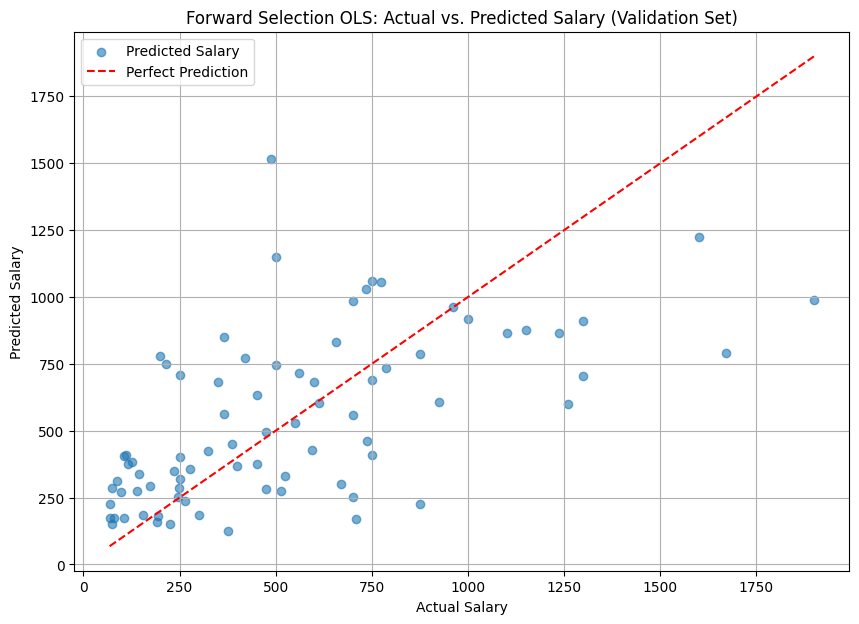

In [ ]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(y_val, y_val_pred_forward, alpha=0.6, label='Predicted Salary')

# Add a diagonal line for perfect prediction
# The range for the line should cover the extent of both actual and predicted values
min_val_forward = min(y_val.min(), y_val_pred_forward.min())
max_val_forward = max(y_val.max(), y_val_pred_forward.max())
plt.plot([min_val_forward, max_val_forward], [min_val_forward, max_val_forward], color='red', linestyle='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Forward Selection OLS: Actual vs. Predicted Salary (Validation Set)')

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Collect R-squared values for each model
r_squared_data = {
    'Model': [
        'Original Full Linear Model',
        'Backward Selection OLS Model',
        'Forward Selection OLS Model',
        'Optimal Ridge Model',
        'Optimal Lasso Model'
    ],
    'Training R-squared': [
        r2_train, # From original linear model
        r2_train_backward, # From backward selection OLS
        r2_train_forward, # From forward selection OLS
        r2_train_ridge, # From optimal Ridge model
        r2_train_lasso # From optimal Lasso model
    ],
    'Validation R-squared': [
        r2_val, # From original linear model
        r2_val_backward, # From backward selection OLS
        r2_val_forward, # From forward selection OLS
        r2_val_ridge, # From optimal Ridge model
        r2_val_lasso # From optimal Lasso model
    ]
}

r_squared_comparison_df = pd.DataFrame(r_squared_data)

print("--- R-squared Comparison of All Models ---")
display(r_squared_comparison_df.sort_values(by='Validation R-squared', ascending=False))

--- R-squared Comparison of All Models ---


,Model,Training R-squared,Validation R-squared
1,Backward Selection OLS Model,0.577427,0.347187
3,Optimal Ridge Model,0.570349,0.340972
2,Forward Selection OLS Model,0.554486,0.336131
4,Optimal Lasso Model,0.588602,0.322871
0,Original Full Linear Model,0.589918,0.304021


## 9. Final Conclusions & Findings

### Data Analysis Key Findings

*   **Optimal Polynomial Degree:** An iterative process determined that a polynomial degree of **1** (linear model) was optimal, yielding a validation Mean Squared Error (MSE) of 113379.0381. Higher degrees (2, 3, 4) resulted in significantly increased MSEs, suggesting overfitting or issues with feature generation/model complexity for these cases.
*   **Backward Selection Feature Subset:** A backward selection algorithm, guided by the Akaike Information Criterion (AIC), identified an optimal subset of 11 features for the OLS model: 'AtBat', 'Hits', 'Walks', 'Years', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', and 'Division\_W'. The final model with these features achieved an AIC of 2650.9741.
*   **Backward Selection Model Performance:** The OLS model trained with the features selected by backward selection achieved a validation R-squared of 0.3472 and a validation MSE of 106347.0700.
*   **Ridge Regression Performance:** After scaling features and tuning the regularization parameter, the optimal Ridge model found an `alpha` of 6.1359. It yielded a validation R-squared of 0.3410 and a validation MSE of 107359.4779.
*   **Lasso Regression Performance:** The optimal Lasso model, after hyperparameter tuning, identified an `alpha` of 0.6893. It produced a validation R-squared of 0.3229 and a validation MSE of 110308.2765.
*   **Model Comparison:** The comparative analysis of validation MSEs revealed that the **Backward Selection OLS Model** achieved the lowest validation MSE (106347.0700) among all models evaluated, making it the best-performing model in terms of predictive accuracy on unseen data. The Polynomial Model with degree 1 showed an exceptionally high MSE, indicating a potential issue in its calculation or an extremely poor fit, making it an outlier in the comparison.

### Insights or Next Steps

*   The Backward Selection OLS Model demonstrated the best performance, indicating that a simpler, linear model with a carefully selected subset of features is most effective for this dataset in terms of generalization. This suggests that complex polynomial interactions or aggressive regularization (Ridge/Lasso) did not significantly improve or even slightly deteriorated predictive accuracy on the validation set compared to the parsimonious OLS model.
*   Further investigation into the discrepancy of the Polynomial Model (degree 1) validation MSE with the "Original Full Linear Model" is warranted, as both represent linear relationships but show vastly different validation MSEs (3.39e+11 vs. 1.13e+05). This could be due to differences in feature preparation or an error in MSE assignment. Additionally, exploring ensemble methods or non-linear models like Random Forests or Gradient Boosting could potentially uncover more complex relationships that linear models might miss.
